In [1]:
from pathlib import Path
from tqdm.auto import tqdm
import polars as pl
from transformers import pipeline

#MODEL_ID = "Oxidane/tmr-ai-text-detector"
#MODEL_ID = "openai-community/roberta-base-openai-detector"
MODEL_ID = "fakespot-ai/roberta-base-ai-text-detection-v1"
BATCH_SIZE = 256
MAX_LENGTH = 512

pipe = pipeline(
    "text-classification", model=MODEL_ID, device=0,
    truncation=True, max_length=MAX_LENGTH
    )


def detect(fp: str | Path) -> pl.DataFrame:
    df = pl.read_parquet(fp)
    texts = df["text"].to_list()
    labels, probs = [], []

    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc=Path(fp).name):
        results = pipe([t[:5000] for t in texts[i: i + BATCH_SIZE]], batch_size=BATCH_SIZE)
        labels.extend(r["label"] for r in results)
        probs.extend(r["score"] for r in results)

    return df.with_columns(
        pl.Series("prediction", labels),
        pl.Series("prob", probs),
    )

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [2]:
pipe(["This is a test sentence that is long enough to be meaningful."])

[{'label': 'AI', 'score': 0.9926635026931763}]

In [3]:
# detect("/mnt/Fast2T/data/detection/grok-filtered.parquet").write_parquet(
#     "/mnt/Fast2T/data/detection/grok-finished.parquet")
# detect("/mnt/Fast2T/data/detection/wiki-filtered.parquet").write_parquet(
#     "/mnt/Fast2T/data/detection/wiki-finished.parquet")
detect("/mnt/Fast2T/data/detection/moltbook-filtered.parquet").write_parquet(
    "/mnt/Fast2T/data/detection/moltbook-finished.parquet"
)

moltbook-filtered.parquet:   0%|          | 0/40 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


roberta-v1
0.8428845875
  ai      n=  10,000  label: AI=   9,528 (95.3%)
  grok    n=  10,000  label: AI=   5,430 (54.3%)
  wiki    n=  10,000  label: AI=   2,988 (29.9%)
  cc      n=  10,000  label: AI=      65 ( 0.7%)
  moltbook  n=  10,000  label: AI=   2,429 (24.3%)


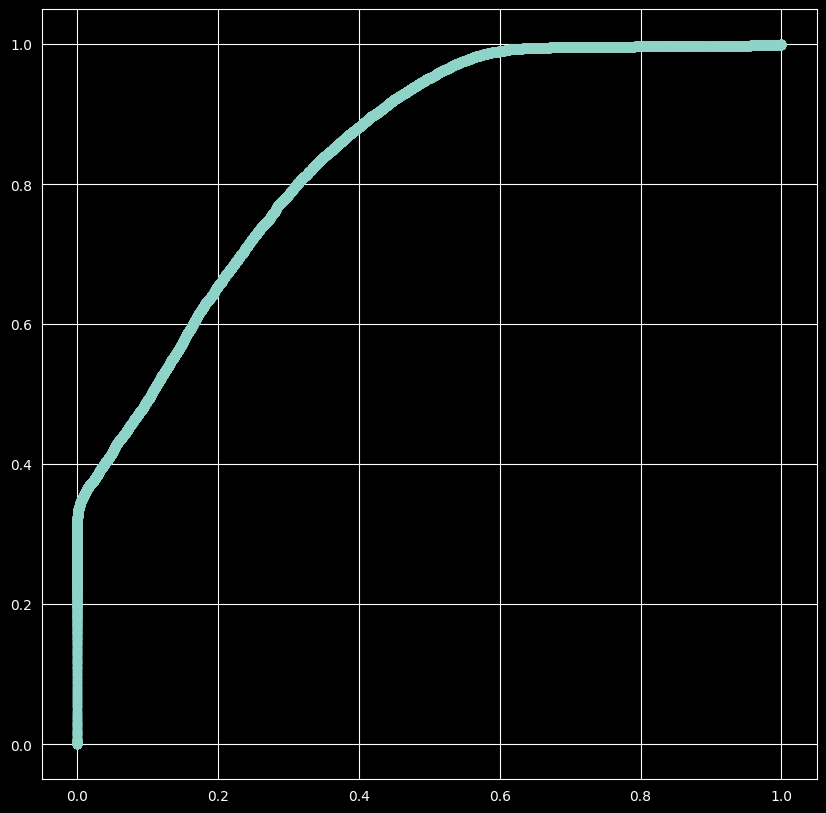

In [6]:
import polars as pl
from sklearn import metrics
import matplotlib.pyplot as plt


def norm(df: pl.DataFrame, label: int) -> pl.DataFrame:
    return (
        df
        .with_columns(
            score=pl
            .when(pl.col("prediction").is_in(["AI", "ai", "Fake"]))
            .then(pl.col("prob"))
            .otherwise(1 - pl.col("prob")),
            pred=pl
            .when(pl.col("prediction").is_in(["AI", "ai", "Fake"]))
            .then(pl.lit("ai"))
            .otherwise(pl.lit("human")),
            label=label
        )
        .select("score", "label", "pred")
    )


for folder in ["roberta-v1"]:
    print(folder)
    wiki = norm(pl.read_parquet(f"/mnt/Fast2T/data/detection/{folder}/wiki-finished.parquet"), 0)
    grok = norm(pl.read_parquet(f"/mnt/Fast2T/data/detection/{folder}/grok-finished.parquet"), 1)
    cc = norm(pl.read_parquet(f"/mnt/Fast2T/data/detection/{folder}/cc-finished.parquet"), 0)
    ai = norm(pl.read_parquet(f"/mnt/Fast2T/data/detection/{folder}/ai-finished.parquet"), 1)
    moltbook = norm(pl.read_parquet(f"/mnt/Fast2T/data/detection/{folder}/moltbook-finished.parquet"), 1)

    data = pl.concat([wiki, grok, cc, ai, moltbook])

    fpr, tpr, thresholds = metrics.roc_curve(data["label"], data["score"], pos_label=1)
    auc = metrics.roc_auc_score(data["label"], data["score"])
    print(auc)

    for name, df in [("ai", ai), ("grok", grok), ("wiki", wiki), ("cc", cc), ("moltbook", moltbook)]:
        n = len(df)
        by_label = (df["pred"] == "ai").sum()
        print(
            f"  {name:6s}  n={n:>8,}"
            f"  label: AI={by_label:>8,} ({by_label / n:>5.1%})"
        )

    precision, recall, pr_thresholds = metrics.precision_recall_curve(
        data["label"], data["score"], pos_label=1
    )

    plt.figure(figsize=(10, 10))
    plt.scatter(fpr, tpr)
    plt.savefig(Path("/mnt/Fast2T/data/detection/") / folder / "roc.png", dpi=150)
    plt.show()

0.8428845875
  ai      n=  10,000  label: AI=   9,528 (95.3%)
  grok    n=  10,000  label: AI=   5,430 (54.3%)
  wiki    n=  10,000  label: AI=   2,988 (29.9%)
  cc      n=  10,000  label: AI=      65 ( 0.7%)
  moltbook  n=  10,000  label: AI=   2,429 (24.3%)


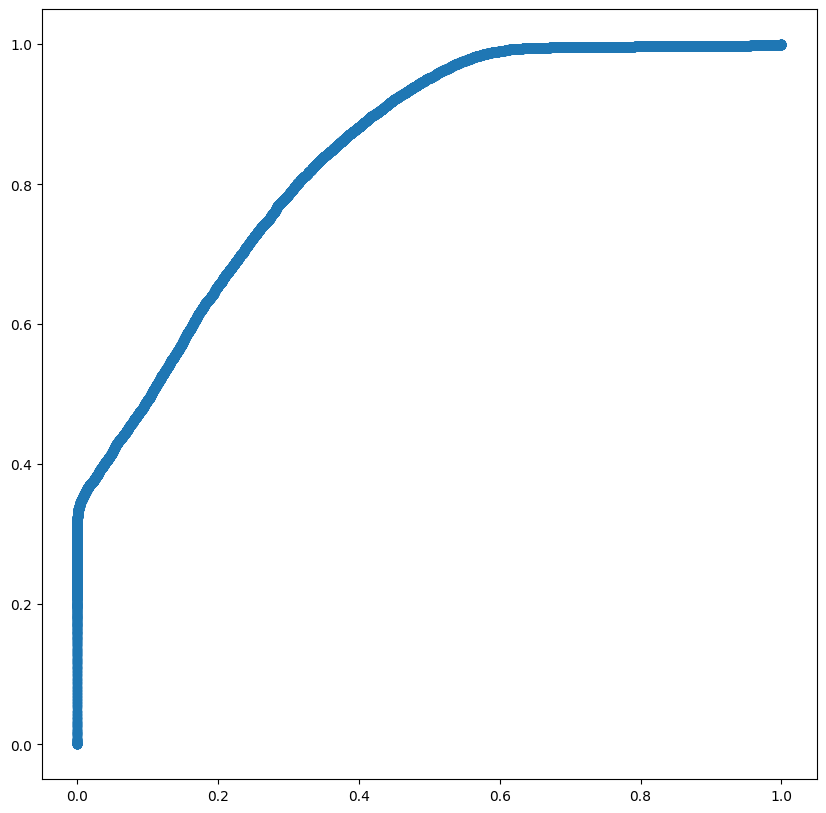

Human (99%):     score < 0.0021
Maybe-Human(95%):score < 0.0021
Maybe-AI (95%):  score >= 0.9272
AI (99%):        score >= 0.9272

ai      AI= 9,409 (94.1%)  mAI=     0 ( 0.0%)  ???=   366 ( 3.7%)  mHu=     0 ( 0.0%)  Hu=   225 ( 2.2%)

grok    AI= 2,685 (26.9%)  mAI=     0 ( 0.0%)  ???= 7,290 (72.9%)  mHu=     0 ( 0.0%)  Hu=    25 ( 0.2%)

wiki    AI= 1,506 (15.1%)  mAI=     0 ( 0.0%)  ???= 7,750 (77.5%)  mHu=     0 ( 0.0%)  Hu=   744 ( 7.4%)

cc      AI=    14 ( 0.1%)  mAI=     0 ( 0.0%)  ???= 1,233 (12.3%)  mHu=     0 ( 0.0%)  Hu= 8,753 (87.5%)

moltbook  AI= 1,592 (15.9%)  mAI=     0 ( 0.0%)  ???= 7,603 (76.0%)  mHu=     0 ( 0.0%)  Hu=   805 ( 8.1%)


In [2]:
import polars as pl
from sklearn import metrics
import matplotlib.pyplot as plt


def norm(df: pl.DataFrame, label: int) -> pl.DataFrame:
    return (
        df
        .with_columns(
            score=pl
            .when(pl.col("prediction").is_in(["AI", "ai", "Fake"]))
            .then(pl.col("prob"))
            .otherwise(1 - pl.col("prob")),
            pred=pl
            .when(pl.col("prediction").is_in(["AI", "ai", "Fake"]))
            .then(pl.lit("ai"))
            .otherwise(pl.lit("human")),
            label=label
        )
        .select("score", "label", "pred")
    )


wiki = norm(pl.read_parquet(f"/mnt/Fast2T/data/detection/roberta-v1/wiki-finished.parquet"), 0)
grok = norm(pl.read_parquet(f"/mnt/Fast2T/data/detection/roberta-v1/grok-finished.parquet"), 1)
cc = norm(pl.read_parquet(f"/mnt/Fast2T/data/detection/roberta-v1/cc-finished.parquet"), 0)
ai = norm(pl.read_parquet(f"/mnt/Fast2T/data/detection/roberta-v1/ai-finished.parquet"), 1)
moltbook = norm(pl.read_parquet(f"/mnt/Fast2T/data/detection/roberta-v1/moltbook-finished.parquet"), 1)

data = pl.concat([wiki, grok, cc, ai, moltbook])

fpr, tpr, thresholds = metrics.roc_curve(data["label"], data["score"], pos_label=1)
auc = metrics.roc_auc_score(data["label"], data["score"])
print(auc)

for name, df in [("ai", ai), ("grok", grok), ("wiki", wiki), ("cc", cc), ("moltbook", moltbook)]:
    n = len(df)
    by_label = (df["pred"] == "ai").sum()
    print(
        f"  {name:6s}  n={n:>8,}"
        f"  label: AI={by_label:>8,} ({by_label / n:>5.1%})"
    )

precision, recall, pr_thresholds = metrics.precision_recall_curve(
    data["label"], data["score"], pos_label=1
)

plt.figure(figsize=(10, 10))
plt.scatter(fpr, tpr)
plt.show()

# AI-side thresholds (precision when predicting AI)
precision_ai, recall_ai, pr_thresh_ai = metrics.precision_recall_curve(
    data["label"], data["score"], pos_label=1
)

# Human-side thresholds (precision when predicting human = flip labels and scores)
precision_hu, recall_hu, pr_thresh_hu = metrics.precision_recall_curve(
    1 - data["label"], 1 - data["score"], pos_label=1
)


def find_threshold(precision, thresholds, target):
    mask = precision[:-1] >= target
    if mask.any():
        return thresholds[mask.nonzero()[0].min()]
    return None


t_ai_99 = find_threshold(precision_ai, pr_thresh_ai, 0.9)
t_ai_95 = find_threshold(precision_ai, pr_thresh_ai, 0.9)
# human thresholds come from flipped scores, so flip back
t_hu_95 = 1 - find_threshold(precision_hu, pr_thresh_hu, 0.9)
t_hu_99 = 1 - find_threshold(precision_hu, pr_thresh_hu, 0.9)

print(f"Human (99%):     score < {t_hu_99:.4f}")
print(f"Maybe-Human(95%):score < {t_hu_95:.4f}")
print(f"Maybe-AI (95%):  score >= {t_ai_95:.4f}")
print(f"AI (99%):        score >= {t_ai_99:.4f}")

thresholds = sorted([t_hu_99, t_hu_95, t_ai_95, t_ai_99])
labels = ["Human", "Maybe-Human", "Uncertain", "Maybe-AI", "AI"]


def bucket(score):
    for i, t in enumerate(thresholds):
        if score < t:
            return labels[i]
    return labels[-1]


for name, df in [("ai", ai), ("grok", grok), ("wiki", wiki), ("cc", cc), ("moltbook", moltbook)]:
    buckets = (
        df.with_columns(
            pl.col("score").map_elements(bucket, return_dtype=pl.Utf8).alias("bucket")
        )["bucket"]
        .value_counts()
        .sort("bucket")
    )
    counts = { row[0]: row[1] for row in buckets.iter_rows() }
    ai_side = counts.get("AI", 0)
    mai_side = counts.get("Maybe-AI", 0)
    unc = counts.get("Uncertain", 0)
    mhu_side = counts.get("Maybe-Human", 0)
    hu_side = counts.get("Human", 0)
    n = len(df)
    print(
        f"\n{name:6s}  "
        f"AI={ai_side:>6,} ({ai_side / n:>5.1%})  "
        f"mAI={mai_side:>6,} ({mai_side / n:>5.1%})  "
        f"???={unc:>6,} ({unc / n:>5.1%})  "
        f"mHu={mhu_side:>6,} ({mhu_side / n:>5.1%})  "
        f"Hu={hu_side:>6,} ({hu_side / n:>5.1%})"
    )

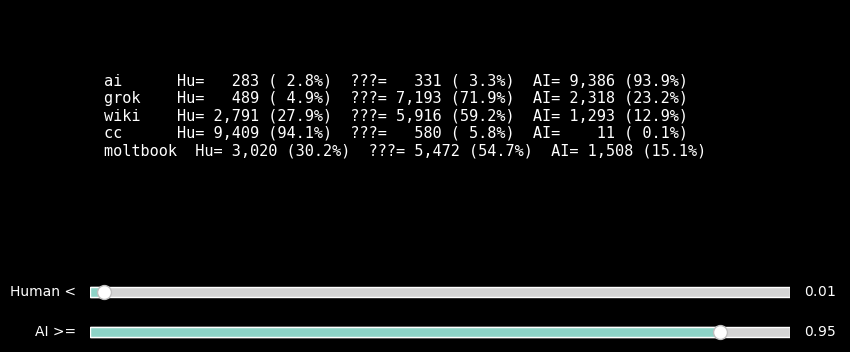

In [17]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

fig, ax = plt.subplots(figsize=(10, 4))
fig.subplots_adjust(bottom=0.35)

ax_hu = fig.add_axes([0.15, 0.15, 0.7, 0.05])
ax_ai = fig.add_axes([0.15, 0.05, 0.7, 0.05])
s_hu = Slider(ax_hu, "Human <", 0.0, 0.5, valinit=0.01)
s_ai = Slider(ax_ai, "AI >=", 0.5, 1.0, valinit=0.95)

datasets = [("ai", ai), ("grok", grok), ("wiki", wiki), ("cc", cc), ("moltbook", moltbook)]
scores = { name: df["score"].to_numpy() for name, df in datasets }


def update(val):
    ax.clear()
    t_hu, t_ai = s_hu.val, s_ai.val
    text = []
    for name in ["ai", "grok", "wiki", "cc", "moltbook"]:
        s = scores[name]
        n = len(s)
        hu = (s < t_hu).sum()
        ai_c = (s >= t_ai).sum()
        unc = n - hu - ai_c
        text.append(
            f"{name:6s}  Hu={hu:>6,} ({hu / n:>5.1%})  ???={unc:>6,} ({unc / n:>5.1%})  AI={ai_c:>6,} ({ai_c / n:>5.1%})"
            )
    ax.text(0.05, 0.5, "\n".join(text), family="monospace", fontsize=11, va="center", transform=ax.transAxes)
    ax.set_axis_off()
    fig.canvas.draw_idle()


s_hu.on_changed(update)
s_ai.on_changed(update)
update(None)
plt.show()